In [71]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["NUMBA_THREADING_LAYER"
] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk

In [72]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======
Depth file already exists. Skipping depth calculation.
====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [73]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [74]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [75]:
hdata.obs['label'] = lb
sk.pp.cal_is(hdata)

✅ 找到已缓存的 IS 单细胞绝缘分矩阵 /Users/ckw/warehouse/metacell/stark/test_output/is_vec_50000.npy，正在直接挂载 ...


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

🕵️‍♂️ 成功提取出这 4 种细胞，共计 200 个单细胞参与亚群分析。


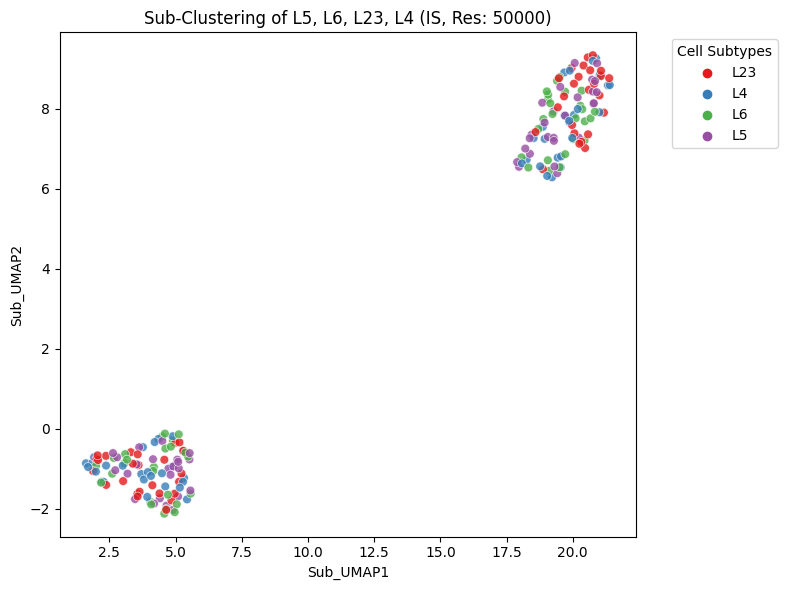

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

res = 50000 
is_mat = hdata.views_is[res]

# =========================================================
# 🎯 第0步：提取特定的细胞亚群 (比如你想看的 L5 和 L6)
# =========================================================
# 请将你实际数据中代表 L5 和 L6 的准确字符串填好，比如 ['L5', 'L6'] 
target_types = ['L5', 'L6', 'L23','L4']

# 拿到布尔索引，并切分数据
subset_mask = hdata.obs['label'].isin(target_types)
subset_is_mat = is_mat[subset_mask]
subset_obs = hdata.obs[subset_mask].copy()

print(f"🕵️‍♂️ 成功提取出这 {len(target_types)} 种细胞，共计 {len(subset_obs)} 个单细胞参与亚群分析。")

# =========================================================
# 1. 清理基础数据，去除 NaN 边界点
# =========================================================
# 注意，这里我们根据切分出来的 subset_is_mat 去获取 mask
valid_bins_mask = ~np.isnan(subset_is_mat).any(axis=0)
clean_subset_mat = subset_is_mat[:, valid_bins_mask]

# =========================================================
# 2. 计算跨这些被保留细胞的方差，重新筛选高变 Bins
# =========================================================
# 这里是重点！只在这特定几种细胞间差异最大的 top bins 才会被保留
bin_variances = np.var(clean_subset_mat, axis=0)
# 因为细胞变少了，我们可以适当减少特征以防维度过高过拟合，比如取前 1500~2000
top_k = 1000
hvb_indices = np.argsort(bin_variances)[::-1][:top_k]
hvb_mat = clean_subset_mat[:, hvb_indices]

# =========================================================
# 3. PCA 降维 & UMAP 二次降维
# =========================================================
scaler = StandardScaler()
hvb_scaled = scaler.fit_transform(hvb_mat)
# 对于少量细胞的亚群，n_components 不要太大，15-30 就够了
pca = PCA(n_components=15, random_state=42)
pca_vec = pca.fit_transform(hvb_scaled)

# 参数也可随心情微调：n_neighbors越小，局部小簇分离越明显；min_dist越小，点越挨在一起
umap_model = UMAP(n_neighbors=10, min_dist=0.05, random_state=42)
umap_vec = umap_model.fit_transform(pca_vec)

subset_obs['Sub_UMAP1'] = umap_vec[:, 0]
subset_obs['Sub_UMAP2'] = umap_vec[:, 1]

# =========================================================
# 4. 可视化放大后的亚群 UMAP
# =========================================================
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Sub_UMAP1', 
    y='Sub_UMAP2', 
    hue='label',           
    palette='Set1',        # 因为类别少了，我们可以用颜色反差极大的色板
    data=subset_obs,       
    s=40,                  # 放大了看，点也可以调大一点
    alpha=0.8,
    edgecolor="white",     # 加一点点小白边会让散点看起来更有质感
    linewidth=0.5
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cell Subtypes")
plt.title(f'Sub-Clustering of {", ".join(target_types)} (IS, Res: {res})')
plt.tight_layout()
plt.show()
